# Wine Quality Dataset - Classification

In [85]:
#Import Libraries 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Scikit Learn dataset and  Libraries 
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,accuracy_score,precision_score,f1_score,recall_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV





In [86]:
wine=load_wine(as_frame=True)
df=wine.frame.copy()
X=df.drop(columns=['target'])
y=df['target']
print("----Wine dataset Info----")
X.info()
print(f'Shape of the dataset :{X.shape}')
print('-- Target Class --')
target_count=y.value_counts()
print(target_count)
print('----Statistical description of the dataset----')
X.describe().T


----Wine dataset Info----
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    flo

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


Dataset Quality Analysis :
 - From the above details we can infer that the dataset doesnt contain any missing values , hence we dont need to handle nulls.
 - We have 13 features and 178 rows of values for each feature. The dataset is clean
 -The target class has 3 values - 0,1,2
 - Based on the 13 features the wine is classified into 3 classes (0,1,2)
Statistical Analysis of Numerical Features :
 - Alcohol : min-max values ranges between (11.03-14.83) , mean: 13 ,looking at the distribution we can infer that theres no outliers and the feature has clean values 
 - Malic Acid : mean -2.33 and max -min values ranges between (0.74-5.8)
 -Ash : max min values ranges between (1.36-3.23) ,no outliers in the column data 
 -Alcalinity of Ash : ranges between (10-30) and mean value is around 20 , which seems like a good distribution
 -Magnesium :
 -Total Phenols :
 -Flavanoids :
 -Non Flavanoid Phenols :
 -Proanthocyanins :
 -Color intensity :
 -Hue :
 -od280/od315_of_diluted_wines :
 -Proline :














# Exploratory Data Anslysis (EDA) - Univariant Analysis 


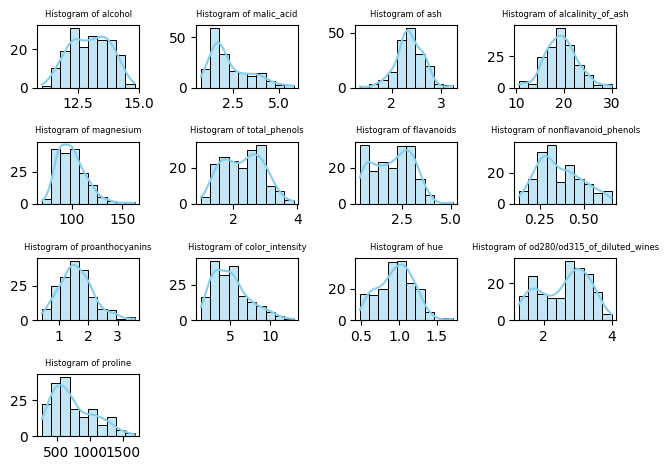

In [87]:
# Get all numeric cols 
import math
num_cols=df.drop(columns=['target']).columns.tolist()
n_cols = 4 # Number of plots per row 
n_rows =math.ceil(len(num_cols)/n_cols)
plt.Figure(figsize=(5*n_cols,4*n_rows))
# Histograms for Numeric col Analysis 
for i,col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(data=df,x=col,kde=True,color='skyblue',bins=10)
    plt.title(f'Histogram of {col}',fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()    

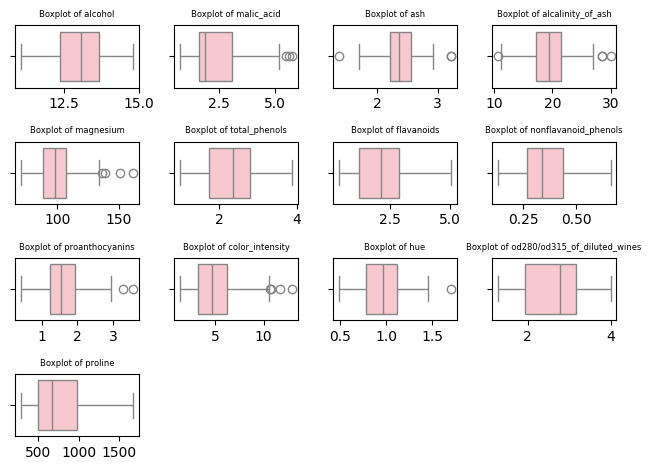

In [88]:
# Boxplot for outlier detection 
n_cols = 4 # Number of plots per row 
n_rows =math.ceil(len(num_cols)/n_cols)
plt.Figure(figsize=(5*n_cols,4*n_rows))
# Histograms for Numeric col Analysis 
for i,col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(data=df,x=col,color='pink')
    plt.title(f'Boxplot of {col}',fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()   

Insights from the above Histogram and Boxplot :
 1.Some Features are Right skewed -
  * Malic Acid
  * Magnesium
  * Color Intensity 
  * Proline
  These features have mostly very low values , only few high values stretch the distribution 
 2.Features like alcohol ,ash,alcalinity of ash,total phenols are slightly symetrical hence indicating a well balanced feature
 3.Spread/Variability : Notice the width of the box -> proline ,total_phenols,flavanoid and od280/od315_of_diluted_wines . These features are highly variable and carry strong distinguishing power
 4. Feature Scaling is required 
 5. We also notice some outliers in features like malic_acid,magnesium,color intensity and proanthocyanins . Might required capping or transformations on these features. 


# Exploratory Data Analysis (EDA): Bivariant Analysis (Features Vs Target)

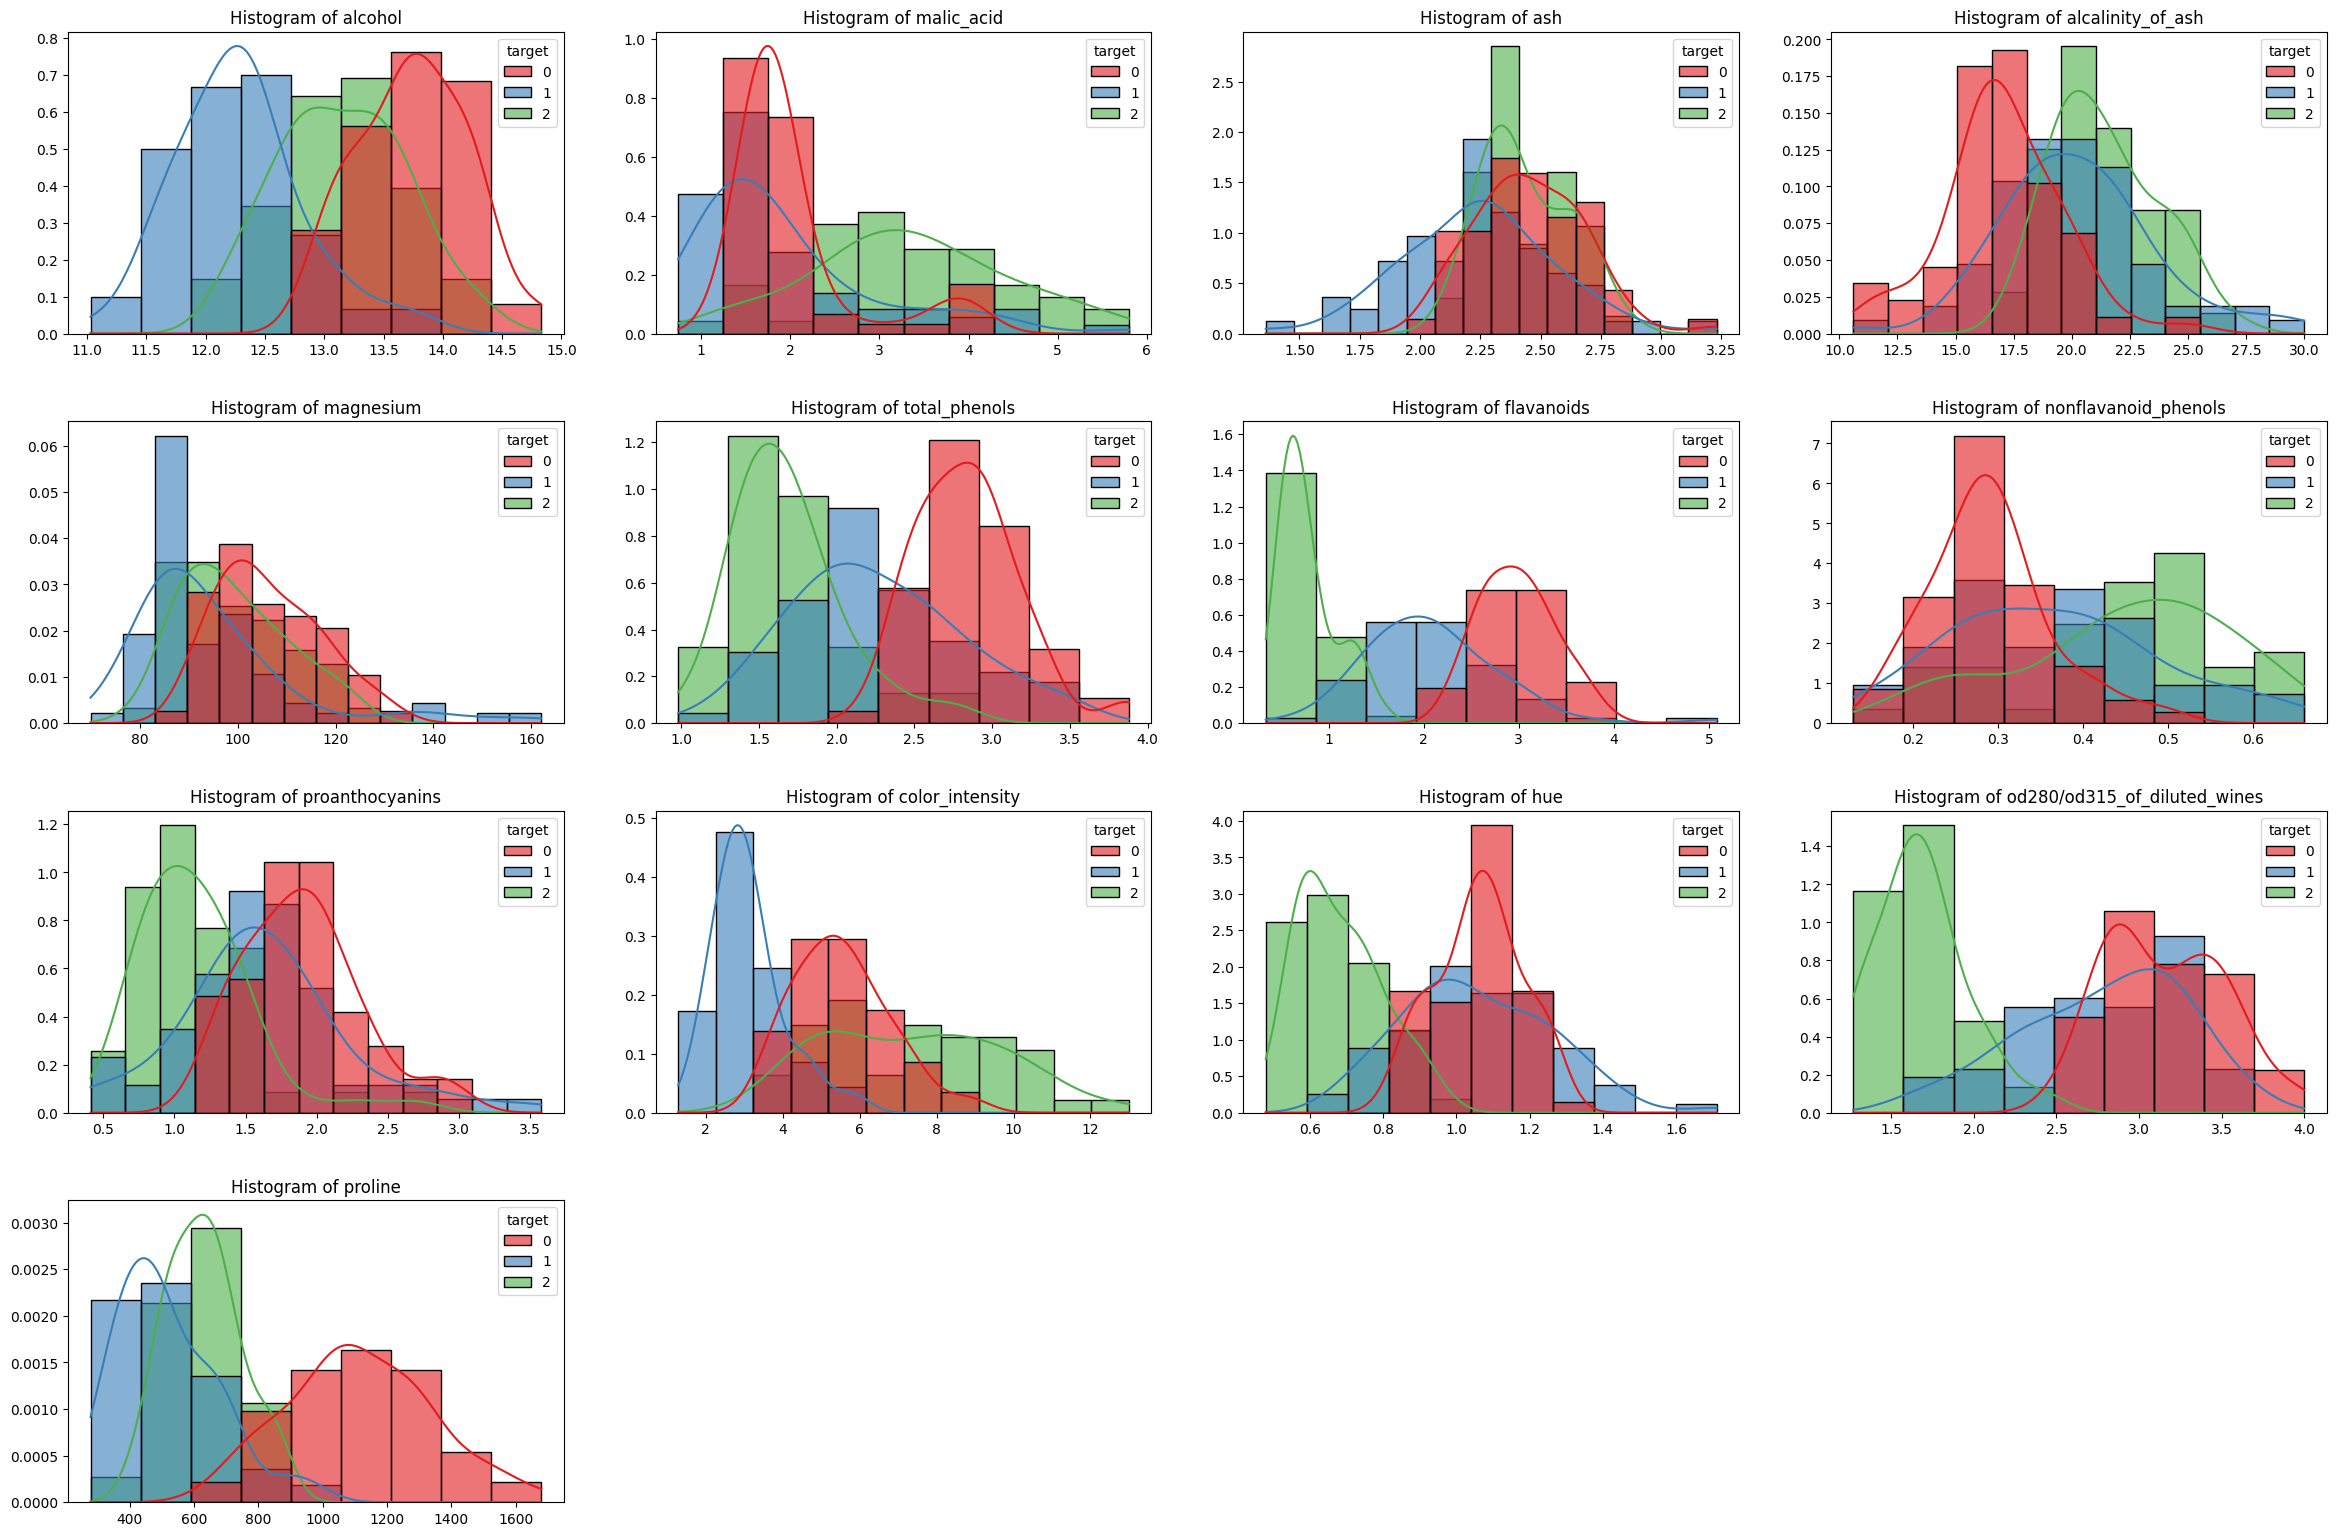

In [89]:
# Histogram with Hue paramter as the Target 
n_cols = 4 # Number of plots per row 
n_rows =math.ceil(len(num_cols)/n_cols)
plt.figure(figsize=(6*n_cols, 4*n_rows))  # much bigger

# Histograms for Numeric col Analysis 
for i,col in enumerate(num_cols):
    plt.subplot(n_rows,n_cols,i+1)
    sns.histplot(data=df,x=col,kde=True,hue=y,alpha=0.6,palette='Set1', stat='density', common_norm=False)
    plt.title(f'Histogram of {col}',fontsize=12)
    plt.xlabel('')
    plt.ylabel('')
    #plt.legend([],[], frameon=False)  # remove repeated legend
plt.tight_layout(pad=3.0)  # more spacing
plt.show()

Correlation Analysis 

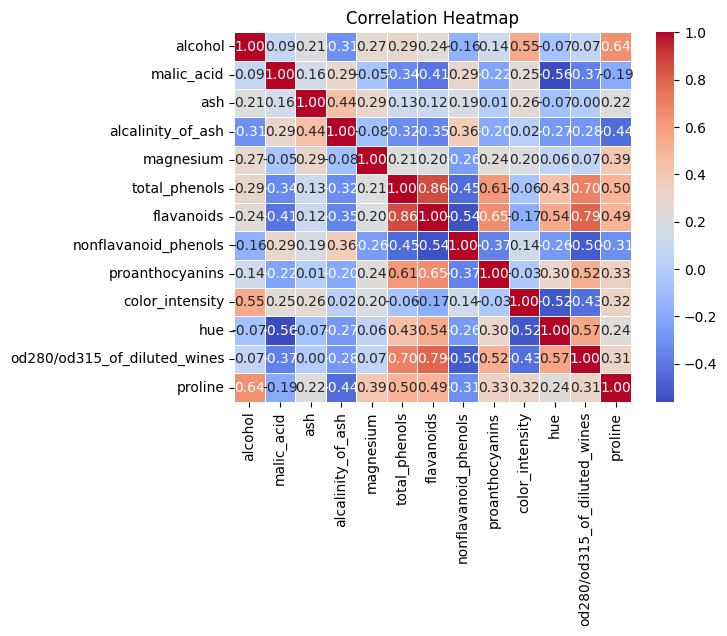

In [90]:
plt.Figure(figsize=(12,10))
correlation_matrix=X[num_cols].corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Feature Engineering and Data Preprocessing

In [93]:
# Split the dataset into train and test sets 
#stratify=y guarantees proportional split of the Target col 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(f'Training sample:{X_train.shape[0]},Test sample:{X_test.shape[0]}')

# Baseline Model 
baseline_model =LogisticRegression(solver='lbfgs',max_iter=1000,random_state=42)
baseline_model.fit(X_train,y_train)
#Predict and evaluate
y_pred=baseline_model.predict(X_test)
print(f'Baseline Model  Accuracy:{accuracy_score(y_test,y_pred)}')
print(f'-----Baseline Model Classification Report-----')
print(f'{classification_report(y_test,y_pred)}')



Training sample:142,Test sample:36
Baseline Model  Accuracy:0.9444444444444444
-----Baseline Model Classification Report-----
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.93      0.93      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



c:\Users\ali59\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Model Building : Multi class Logistic Regression 

In [92]:
# Create a pipeline with Standard scaler and Logistic regression
#  For multiclass with solver='lbfgs', scikit-learn uses multinomial (Softmax) behavior automatically.
multi_Class_pipeline=Pipeline(
    [
        ('scaler',StandardScaler()),
        ('log',LogisticRegression(solver='lbfgs',max_iter=1000,random_state=42))
    ]
)

# Train your model 
multi_Class_pipeline.fit(X_train,y_train)
#Predict and evaluate
y_pred_m=multi_Class_pipeline.predict(X_test)
print(f'Multi Class Model Accuracy:{accuracy_score(y_test,y_pred_m)}')
print(f'-----Multi Class Model Classification Report-----')
print(f'{classification_report(y_test,y_pred_m)}')



Multi Class Model Accuracy:0.9722222222222222
-----Multi Class Model Classification Report-----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

